In [1]:
import pandas as pd
import itertools
import numpy as np
import krippendorff
import matplotlib.pyplot as plt
import os
import importlib
import pickle

import create_best_subsample

# Some tests

In [ ]:
df =  create_best_subsample.read_files("MQI_MATCON_dataset.csv")

# 1. Get rater columns (those whose name starts with "Rater ")
rater_cols = [c for c in df.columns if c.startswith("Rater ")]

# 2. Initialize an empty square DataFrame for pairwise Krippendorff's alpha
result = pd.DataFrame(index=rater_cols, columns=rater_cols, dtype=float)
n_common = pd.DataFrame(index=rater_cols, columns=rater_cols, dtype=float)

# 3. Loop over all unique pairs of raters
for r1, r2 in itertools.combinations(rater_cols, 2):
    
    # Keep only rows where both raters provided a rating (no NaN)
    sub = df[[r1, r2]].dropna()
    
    # Skip pairs with fewer than 30 samples in common
    if len(sub) < 10:
        continue
    
    # Prepare data for krippendorff: shape (n_raters, n_items) -> here 2 x N
    data = np.array([sub[r1].values, sub[r2].values])
    
    # Compute Krippendorff's alpha
    alpha = krippendorff.alpha(reliability_data=data)
    
    # Fill the matrix symmetrically
    result.loc[r1, r2] = alpha
    n_common.loc[r1, r2] = n_common.loc[r2, r1] = len(sub)

In [ ]:
# Extract the best pairs
upper_mask = np.triu(np.ones(result.shape, dtype=bool), k=1)

pairs_alpha = result.where(upper_mask).stack()        
pairs_n     = n_common.where(upper_mask).stack()      

pairs = (
    pd.DataFrame({"alpha": pairs_alpha, "n_common": pairs_n})
    .dropna()
    .sort_values(by=["alpha", "n_common"], ascending=[False, False])
)

# Top-10 pairs
top10 = pairs.head(10)
print(top10)


                      alpha  n_common
Rater 17 Rater 42  1.000000      10.0
Rater 19 Rater 60  1.000000      10.0
Rater 38 Rater 9   0.831633      17.0
Rater 20 Rater 45  0.791209      10.0
Rater 24 Rater 45  0.776119      20.0
Rater 42 Rater 54  0.757447      10.0
Rater 2  Rater 45  0.750000      23.0
Rater 10 Rater 56  0.712644      13.0
Rater 19 Rater 20  0.699029      16.0
Rater 45 Rater 56  0.694915      23.0


In [ ]:
# 5. Build best subsample (accumulate data until reaching target number of items)
selected_pairs = []
selected_items = pd.DataFrame()  # rows = items, columns = ratings
total_items = 0
TARGET = 70

for (r1, r2), row in pairs.iterrows():

    # subset with no missing values for the pair
    sub = df[[r1, r2]].dropna()

    # how many new items ?
    n = len(sub)

    # otherwise keep the full pair
    selected_pairs.append((r1, r2))
    selected_items = pd.concat([selected_items, sub], axis=0)

    total_items += n

    # if total items exceeds the limit, stop
    if total_items >= TARGET:
        break

print("\nSelected pairs:", selected_pairs)
print("Total items:", total_items)


Selected pairs: [('Rater 17', 'Rater 42'), ('Rater 19', 'Rater 60'), ('Rater 38', 'Rater 9'), ('Rater 20', 'Rater 45'), ('Rater 24', 'Rater 45'), ('Rater 42', 'Rater 54')]
Total items: 77


In [ ]:
importlib.reload(create_best_subsample)

In [ ]:
final_df, current_alpha, selected_pairs = create_best_subsample.create_best_subsample("CLASS_CLTS_dataset.csv", min_alpha=0.5)

000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000004000000000100000000000000000000000000000000000000000000000000passé par l'erreur

=== Subsample Summary ===
Final dataset shape: (0, 0)
Final Krippendorff's alpha: 1.000
Number of selected pairs: 0
Number of unique raters involved: 0


# Check CLASS number of raters

In [ ]:
df = pd.read_csv(
        "/ICPSR_36095/1 Class observations/36095-0001-Data.tsv",
        dtype={"OBSID": "string", 'CHAPNUM': "string", "RATERID": "string"},
        encoding="utf-8",
        sep="\t",
        low_memory=False,
    )

In [ ]:
# 1. Count number of unique raters per (OBSID, CHAPNUM)
rater_counts = (
    df
    .groupby(["OBSID", "CHAPNUM"])["RATERID"]
    .nunique()
    .reset_index(name="n_raters")
)

# 2. Pivot to wide format: rows = OBSID, columns = CHAPNUM, values = n_raters
wide_counts = (
    rater_counts
    .pivot(index="OBSID", columns="CHAPNUM", values="n_raters")
    .fillna(0)
    .astype(int)
)

# Sort columns by CHAPNUM
wide_counts = wide_counts.sort_index(axis=1)

CHAPNUM  1  2  3  4  5  6  7  8
OBSID                          
10       1  1  1  1  0  0  0  0
100      1  1  1  1  0  0  0  0
1005     1  1  1  1  0  0  0  0
1006     1  1  0  0  0  0  0  0
1007     1  1  1  0  0  0  0  0


In [ ]:
count_gt1 = (wide_counts > 1).sum()
print(count_gt1)
print(f'Number of items rated more than once: {count_gt1.sum()}')

CHAPNUM
1    2
2    1
3    1
4    1
5    0
6    0
7    0
8    0
dtype: int64
Number of items rated more than once: 5


# Create subsets

In [ ]:
folder_path = "../balanced_subsets"

files = os.listdir(folder_path)
MQI_files = [f for f in files if f.startswith("MQI")]
print(len(MQI_files))

40


In [ ]:
importlib.reload(create_best_subsample)

In [ ]:
for filename in MQI_files:
    subset_ok=False
    quit=="n"

    print("*************************")
    print(filename, end="")
    final_df, current_alpha, selected_pairs = create_best_subsample.create_best_subsample(filename)

    response = input("Good enough?")
    subset_ok = True if response=="y" else False
    
    while not subset_ok:
        quit = input("Skip?")
        if quit=="y":
            break
        
        while True:
            try:
                target_n = int(input("target_n"))
                break
            except ValueError:
                pass
        while True:
            try:
                min_alpha = float(input("min_alpha"))
                break
            except ValueError:
                pass

        final_df, current_alpha, selected_pairs = create_best_subsample.create_best_subsample(filename, target_n, min_alpha)

        response = input("Is the subset good enough")
        subset_ok = True if response=="y" else False
    

    if not quit=="y":
        final_filename = "subsets/" + filename[:-11] + str(len(final_df)) + "_" + str(f"{current_alpha:.2f}") + ".csv"
        print(final_filename)
        final_df.to_csv(final_filename, index=False, encoding="utf-8")
    else:
        print("file not saved")
    print()


*************************
MQI_STEXPL_dataset.csv
=== Subsample Summary ===
Final dataset shape: (1433, 36)
Final Krippendorff's alpha: 0.702
Number of selected pairs: 38
Number of unique raters involved: 30


## Visualization

In [ ]:
folder_path = "../balanced_subsets"

subset_files = os.listdir(folder_path)
print(len(subset_files))

44


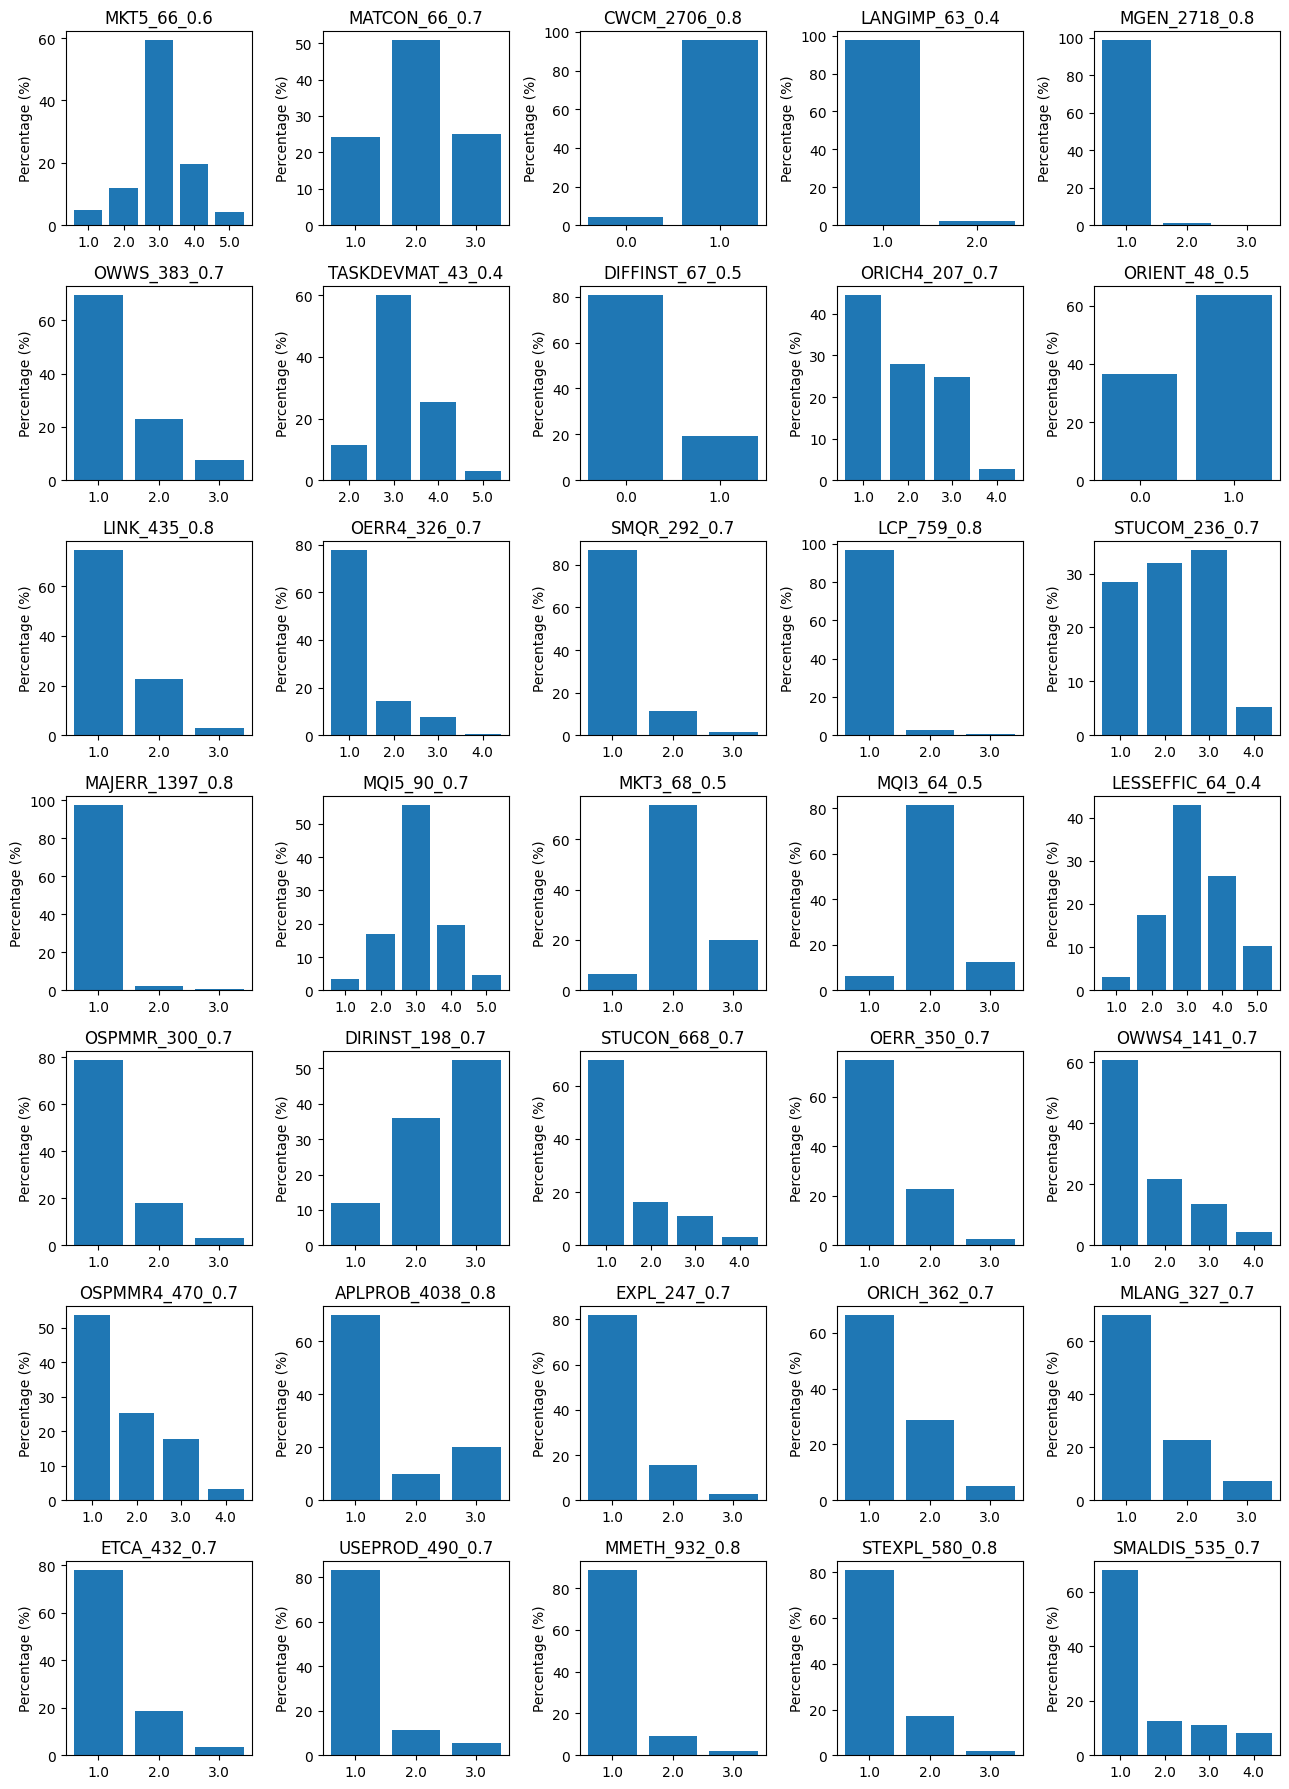

In [ ]:
fig, ax = plt.subplots(figsize=(13, 18), nrows=7, ncols=5)
axes = ax.flatten()

for filename, ax in zip(subset_files, axes):
    df = pd.read_csv(
        f"subsets/{filename}",
        encoding="utf-8",
        low_memory=False,
    )
    df.drop(columns=['NCTETID', 'OBSID', 'DISTRICT', 'SCHOOLYEAR_SP', 'full_text'], inplace=True)
    try:
        df.drop(columns=['CHAPNUM'], inplace=True)
    except:
        pass

    counts = df.stack().value_counts(normalize=True) * 100
    index = sorted(counts.index)
    counts = counts.reindex(index)

    ax.bar(counts.index.astype(str), counts.values)
    ax.set_ylabel("Percentage (%)")
    ax.set_title(filename[4:-5])

plt.tight_layout()
plt.show()

# Create balanced subsets

In [ ]:
folder_path = "datasets"

files = os.listdir(folder_path)
MQI_files = [f for f in files if f.startswith("MQI")]
print(len(MQI_files))

50


In [ ]:
importlib.reload(create_best_subsample)

In [ ]:
MQI_files=["MQI_MATCON_dataset.csv", "MQI_MQI3_dataset.csv"]
for filename in MQI_files:
    subset_ok=False
    quit=="n"

    print("*************************")
    print(filename, end="")
    final_df, current_alpha, selected_pairs = create_best_subsample.create_best_subsample(filename)

    response = input("Good enough?")
    subset_ok = True if response=="y" else False
    
    while not subset_ok:
        quit = input("Skip?")
        if quit=="y":
            break
        
        while True:
            try:
                target_n = int(input("target_n"))
                break
            except ValueError:
                pass
        while True:
            try:
                min_alpha = float(input("min_alpha"))
                break
            except ValueError:
                pass

        final_df, current_alpha, selected_pairs = create_best_subsample.create_best_subsample(filename, target_n, min_alpha)

        response = input("Is the subset good enough")
        subset_ok = True if response=="y" else False
    

    if not quit=="y":
        final_filename = "balanced_subsets/" + filename[:-11] + str(len(final_df)) + "_" + str(f"{current_alpha:.2f}") + ".csv"
        print(final_filename)
        final_df.to_csv(final_filename, index=False, encoding="utf-8")
    else:
        print("file not saved")
    print()


*************************
MQI_MATCON_dataset.csv
=== Subsample Summary ===
Final dataset shape: (93, 11)
Final Krippendorff's alpha: 0.707
Number of selected pairs: 4
Number of unique raters involved: 5
balanced_subsets/MQI_MATCON_93_0.71.csv

*************************
MQI_MQI3_dataset.csv
=== Subsample Summary ===
Final dataset shape: (64, 9)
Final Krippendorff's alpha: 0.580
Number of selected pairs: 3
Number of unique raters involved: 4
balanced_subsets/MQI_MQI3_64_0.58.csv



## Visualization

In [ ]:
folder_path = "balanced_subsets"

subset_files = os.listdir(folder_path)
print(len(subset_files))

34


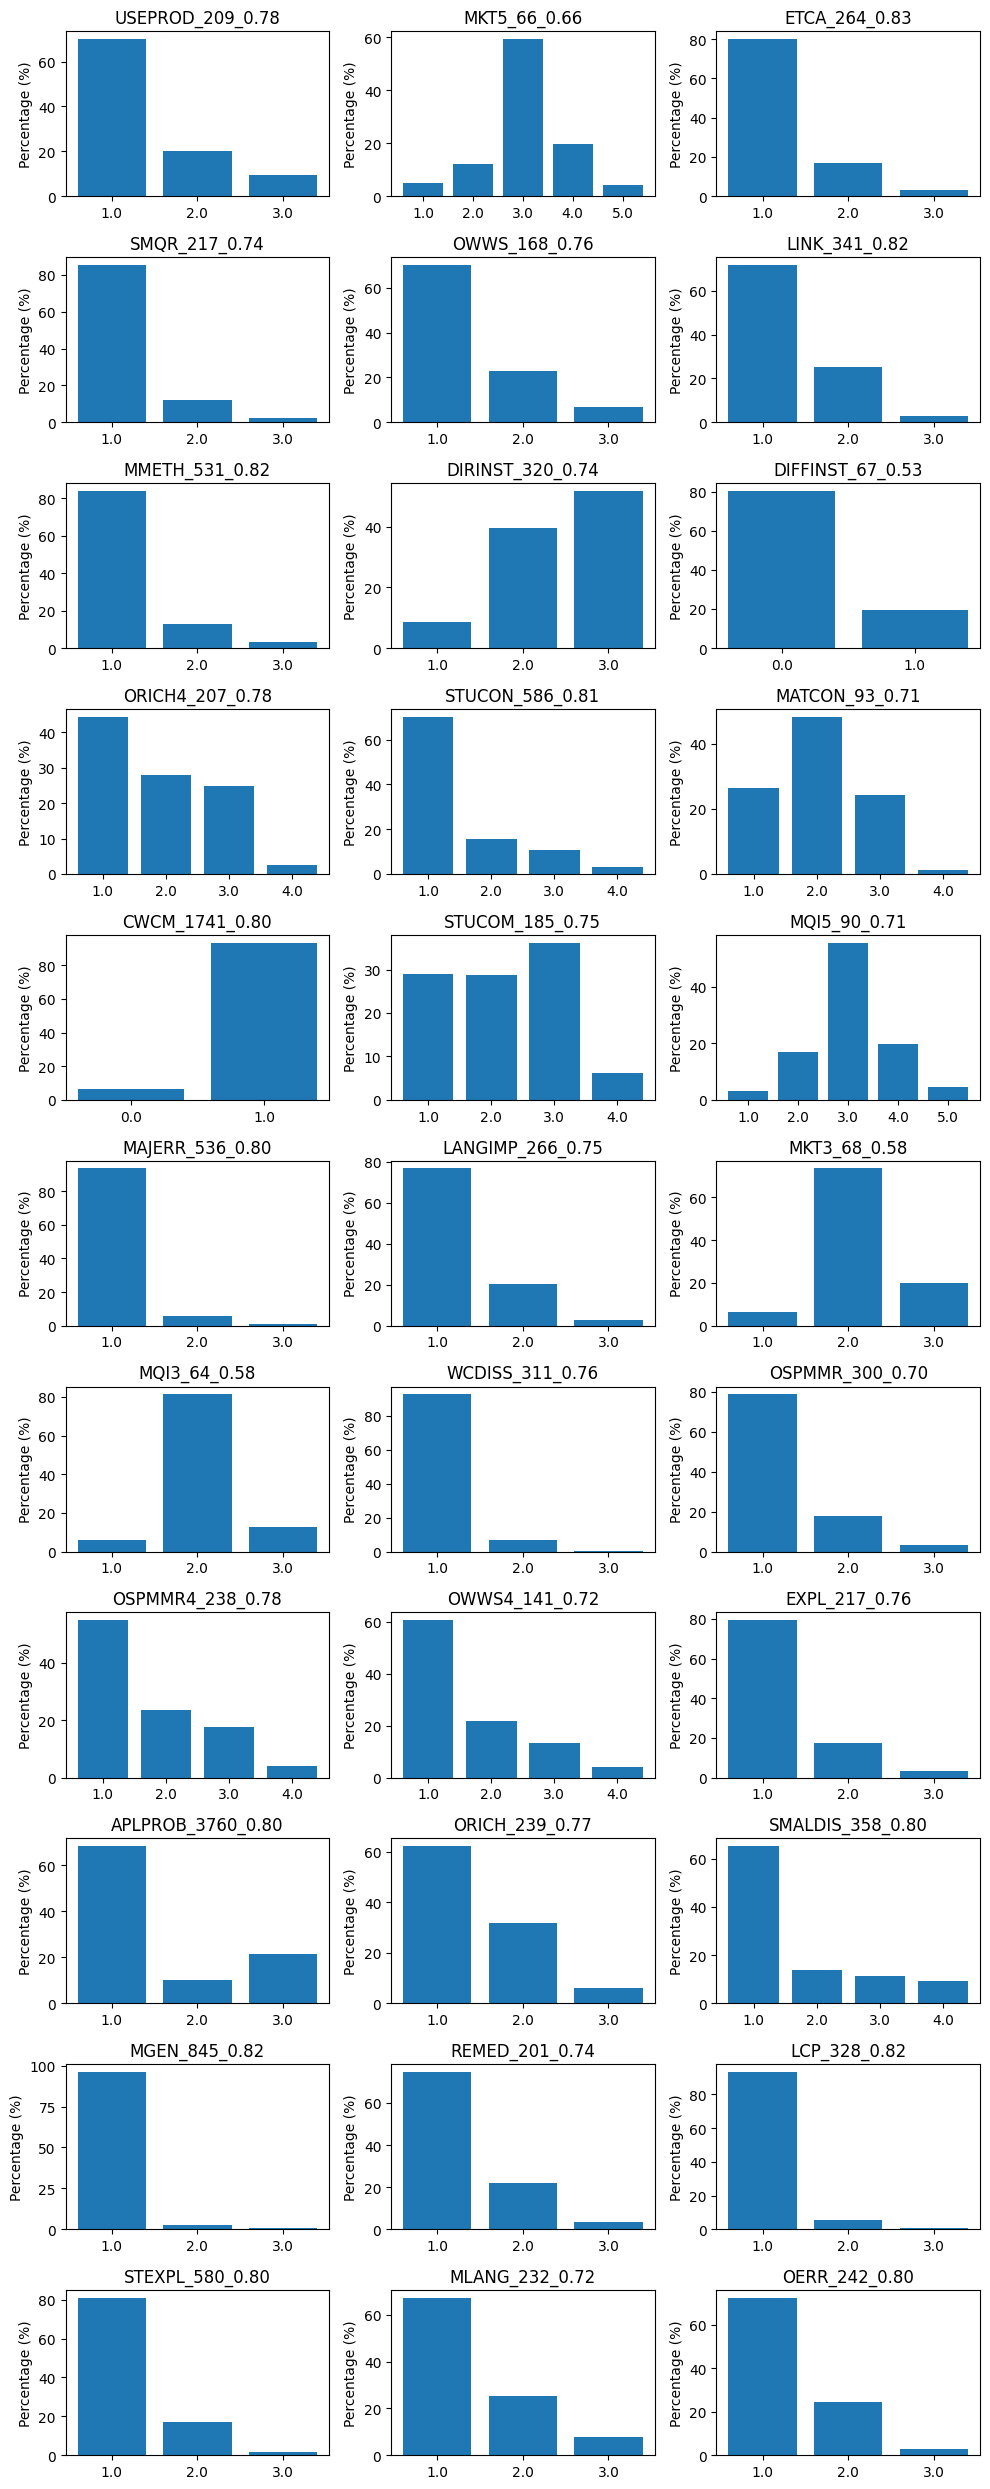

In [ ]:
fig, axes = plt.subplots(figsize=(10, 25), nrows=11, ncols=3)
axes = axes.flatten()

for filename, ax in zip(subset_files, axes):
    df = pd.read_csv(
        f"{folder_path}/{filename}",
        encoding="utf-8",
        low_memory=False,
    )
    df.drop(columns=['NCTETID', 'OBSID', 'DISTRICT', 'SCHOOLYEAR_SP', 'full_text'], inplace=True)
    try:
        df.drop(columns=['CHAPNUM'], inplace=True)
    except:
        pass

    counts = df.stack().value_counts(normalize=True) * 100
    index = sorted(counts.index)
    counts = counts.reindex(index)

    ax.bar(counts.index.astype(str), counts.values)
    ax.set_ylabel("Percentage (%)")
    ax.set_title(filename[4:-4])

plt.tight_layout()
plt.show()


## Visual comparison

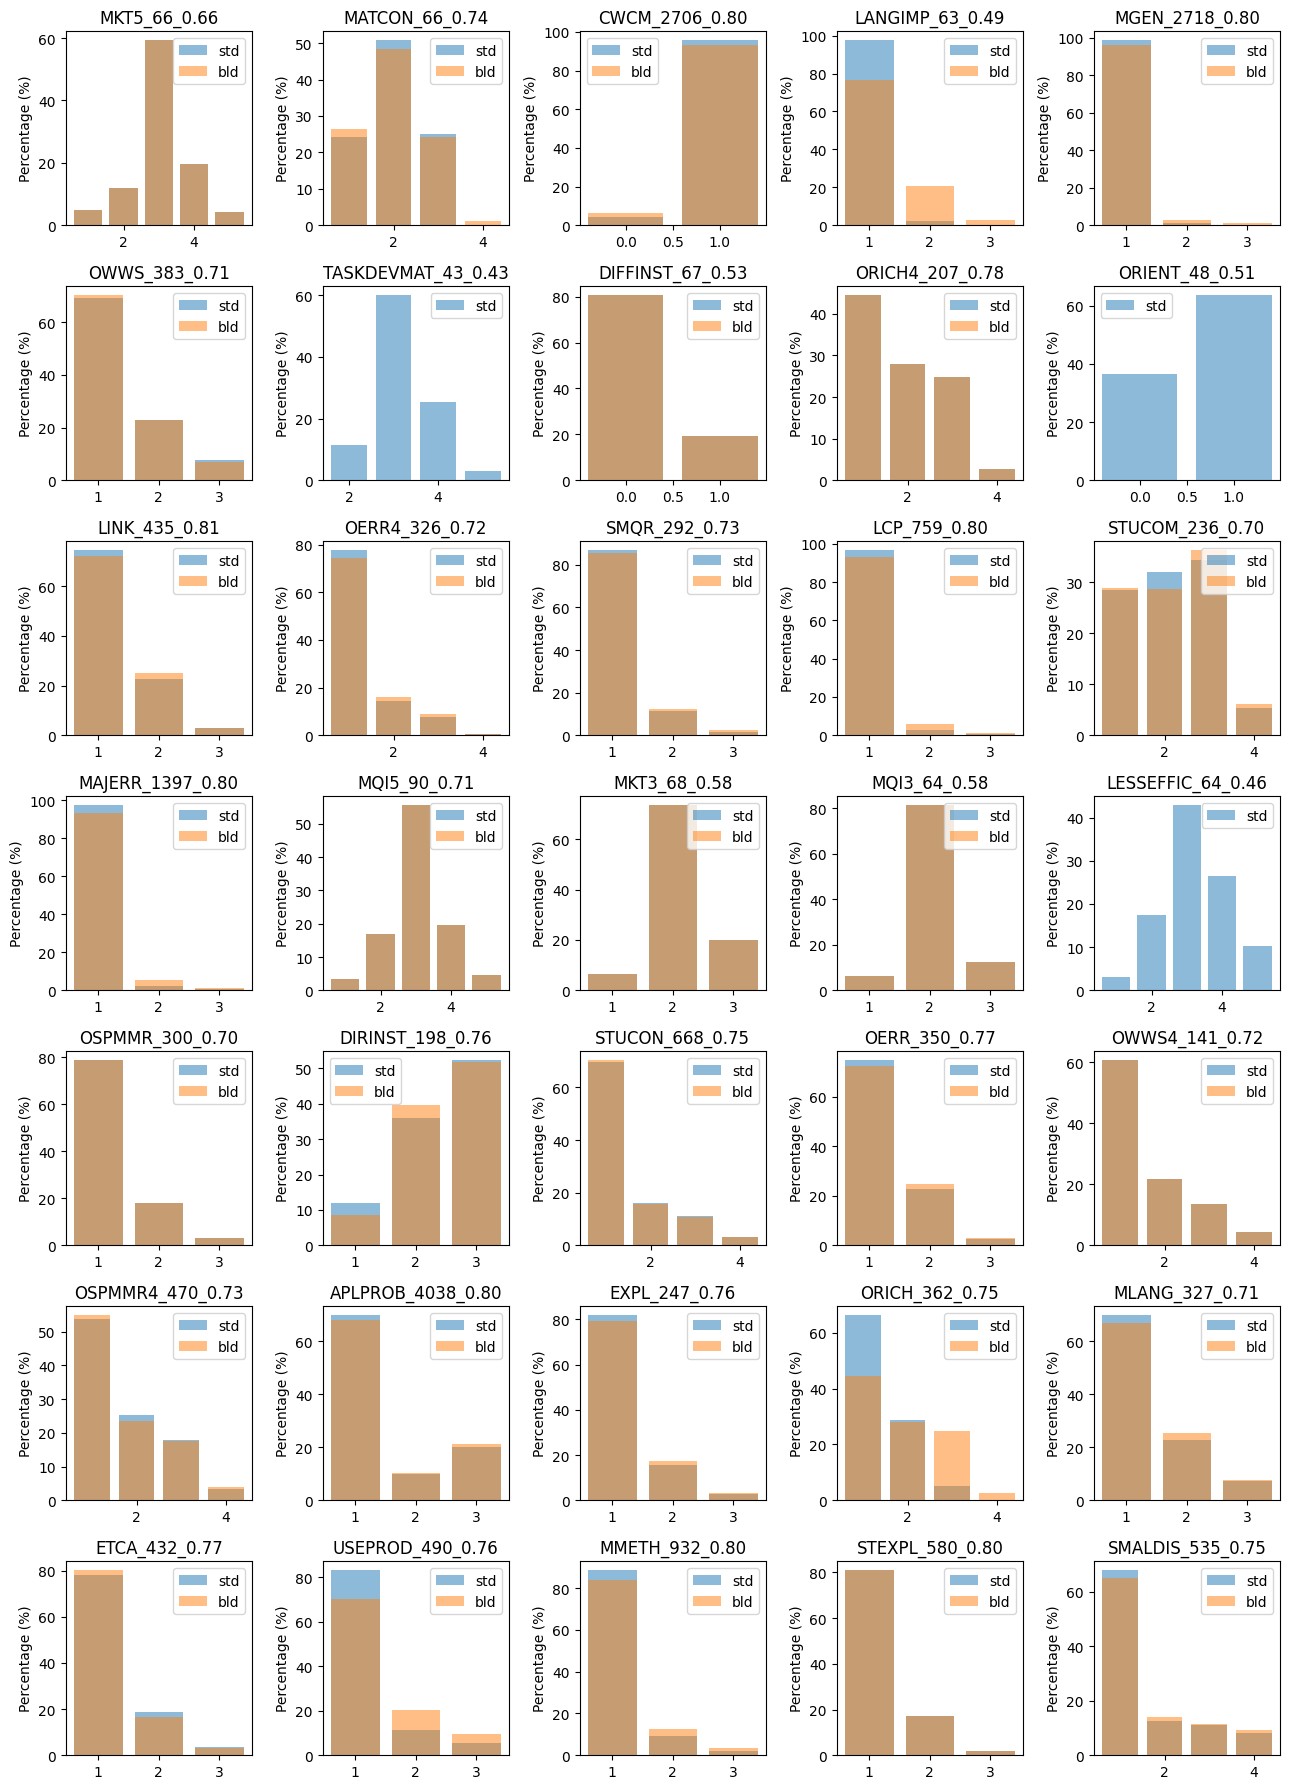

In [ ]:
folder_path = "subsets"
subset_files = os.listdir(folder_path)

balanced_folder_path = "balanced_subsets"
balanced_subset_files = os.listdir(balanced_folder_path)

fig, axes = plt.subplots(figsize=(13, 18), nrows=7, ncols=5)
axes = axes.flatten()

for filename, ax in zip(subset_files, axes):
    code = filename.split("_")[1]

    prefix = f"MQI_{code}"
    matching_files = [f for f in balanced_subset_files if f.startswith(prefix)]

    df1 = pd.read_csv(
        f"{folder_path}/{filename}",
        encoding="utf-8",
        low_memory=False,
    )
    df1.drop(columns=['NCTETID', 'OBSID', 'DISTRICT', 'SCHOOLYEAR_SP', 'full_text'], inplace=True)
    try:
        df1.drop(columns=['CHAPNUM'], inplace=True)
    except:
        pass
    if matching_files:
        df2 = pd.read_csv(
            f"{balanced_folder_path}/{matching_files[0]}",
            encoding="utf-8",
            low_memory=False,
        )
        df2.drop(columns=['NCTETID', 'OBSID', 'DISTRICT', 'SCHOOLYEAR_SP', 'full_text'], inplace=True)
        try:
            df2.drop(columns=['CHAPNUM'], inplace=True)
        except:
            pass
        counts_1 = df1.stack().value_counts(normalize=True) * 100
        counts_2 = df2.stack().value_counts(normalize=True) * 100
        
        index = sorted(set(counts_1.index).union(counts_2.index))
        c1 = counts_1.reindex(index, fill_value=0)
        c2 = counts_2.reindex(index, fill_value=0)

        ax.bar(index, c1, alpha=0.5, label="std")
        ax.bar(index, c2, alpha=0.5, label="bld")

        ax.set_ylabel("Percentage (%)")
        ax.set_title(filename[4:-4])
        ax.legend()
    else:
        counts_1 = df1.stack().value_counts(normalize=True) * 100
        index = sorted(counts_1.index)
        c1 = counts_1.reindex(index, fill_value=0)
        ax.bar(index, c1, alpha=0.5, label="std")
        ax.set_ylabel("Percentage (%)")
        ax.set_title(filename[4:-4])
        ax.legend()
    
plt.tight_layout()
plt.show()


# New transcript segmentation - Use of the balanced subsets method

In [ ]:
# os.chdir("..")
print(os.getcwd())

In [ ]:
importlib.reload(create_best_subsample)

In [ ]:
folder_path = "../datasets"

files = os.listdir(folder_path)
MQI_files = [f for f in files if f.startswith("MQI") and f.endswith(".csv")]
print(len(MQI_files))

50


In [ ]:
for filename in MQI_files:
    subset_ok=False
    quit="x"
    response="x"

    print("*************************")
    print(filename, end="")
    final_df, current_alpha, selected_pairs = create_best_subsample.create_best_subsample(filename, 210, 0.8)

    while response not in ["n", "y"]:
        response = input("Good enough?")
    subset_ok = True if response=="y" else False
    
    while not subset_ok:
        quit="x"
        while quit not in ["n", "y", "all"]:
            quit = input("Skip?")
        if quit=="y" or quit=="all":
            break
        
        while True:
            try:
                target_n = int(input("target_n"))
                break
            except ValueError:
                pass
        while True:
            try:
                min_alpha = float(input("min_alpha"))
                break
            except ValueError:
                pass

        final_df, current_alpha, selected_pairs = create_best_subsample.create_best_subsample(filename, target_n, min_alpha)

        response="x"
        while response not in ["n", "y"]:
            response = input("Good enough?")
        subset_ok = True if response=="y" else False
    

    if not quit=="y" and not quit=="all":
        final_filename = filename[:-11] + str(len(final_df)) + "_" + str(f"{current_alpha:.2f}") + ".csv"
        print(final_filename + " saved")
        final_df.to_csv(final_filename, index=False, encoding="utf-8")
    else:
        print("file not saved")

    if quit=="all":
        print("Stopped")
        break
    print()

print("END")

*************************
MQI_STEXPL_dataset.csv
=== Subsample Summary ===
Final dataset shape: (852, 41)
Final Krippendorff's alpha: 0.801
Number of selected pairs: 34
Number of unique raters involved: 34
MQI_STEXPL_852_0.80.csv saved

*************************
MQI_ORICH4_dataset.csv
=== Subsample Summary ===
Final dataset shape: (263, 25)
Final Krippendorff's alpha: 0.807
Number of selected pairs: 13
Number of unique raters involved: 19
MQI_ORICH4_263_0.81.csv saved

*************************
MQI_TASKDEVMAT_dataset.csv
=== Subsample Summary ===
Final dataset shape: (205, 41)
Final Krippendorff's alpha: 0.351
Number of selected pairs: 18
Number of unique raters involved: 15

=== Subsample Summary ===
Final dataset shape: (52, 30)
Final Krippendorff's alpha: 0.511
Number of selected pairs: 4
Number of unique raters involved: 6
MQI_TASKDEVMAT_52_0.51.csv saved

*************************
MQI_MQI3_dataset.csv
=== Subsample Summary ===
Final dataset shape: (220, 15)
Final Krippendorff's al

# Visualization

In [ ]:
folder_path = "../balanced_subsets"

subset_files = os.listdir(folder_path)
subset_files = [f for f in subset_files if f.endswith(".csv")]
print(len(subset_files))

40


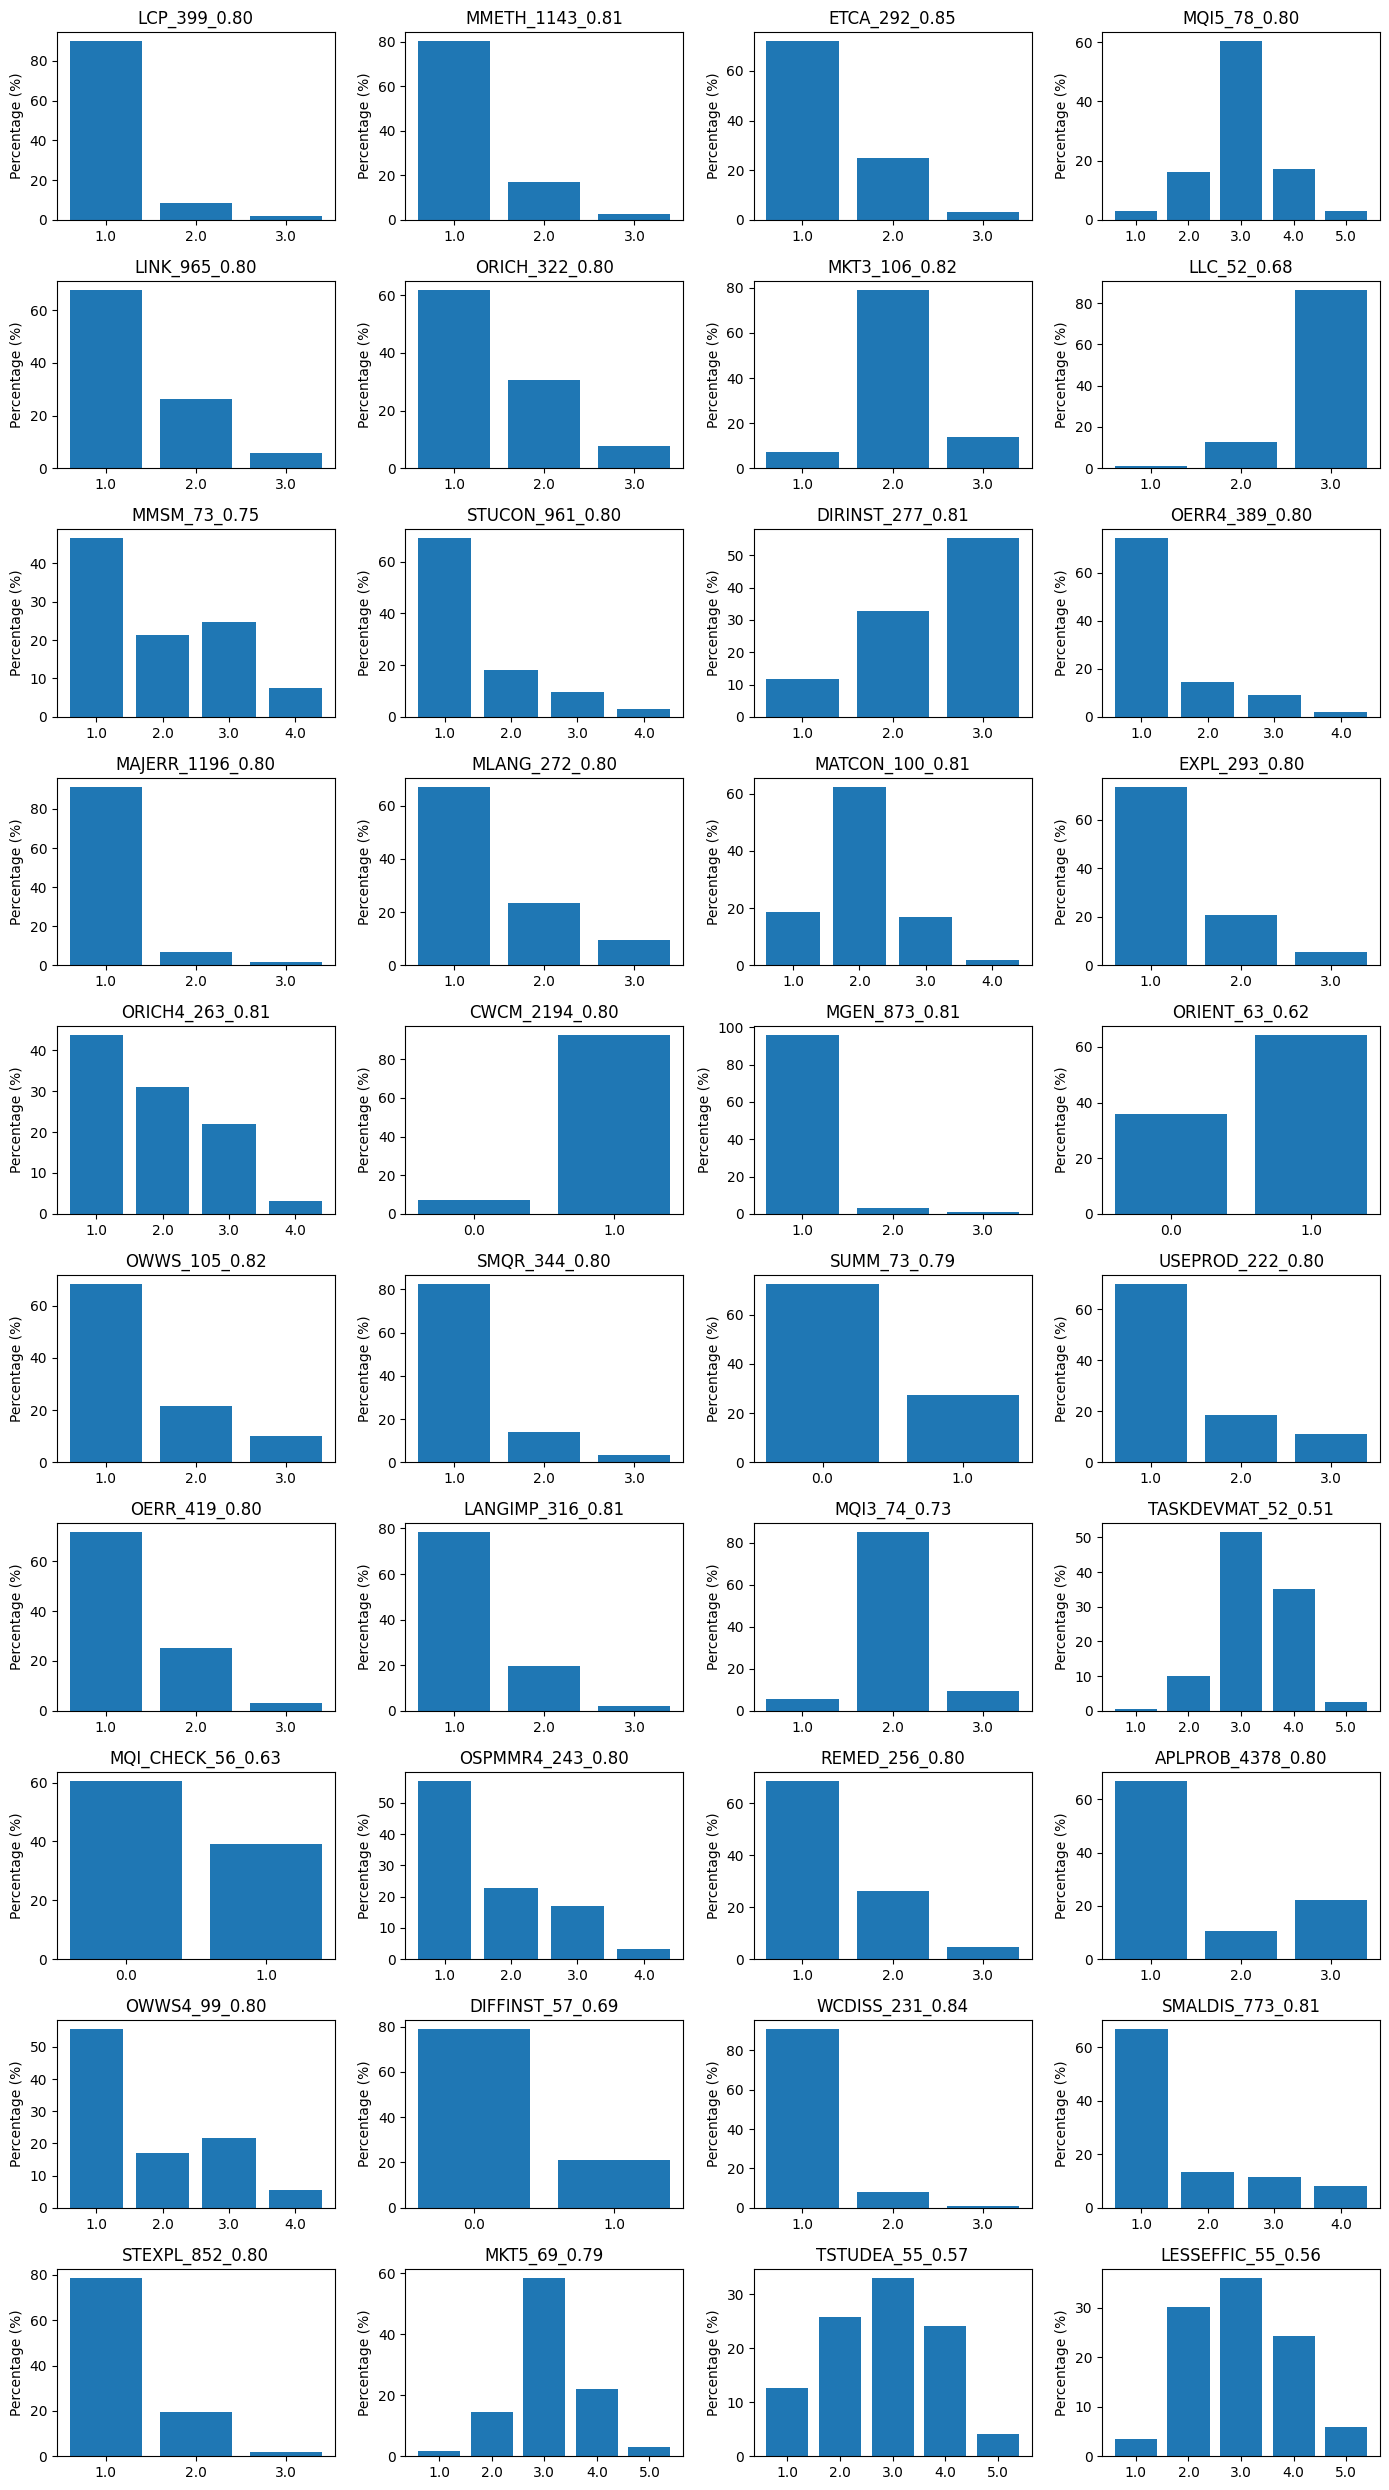

In [ ]:
fig, axes = plt.subplots(figsize=(14, 25), nrows=10, ncols=4)
axes = axes.flatten()

for filename, ax in zip(subset_files, axes):
    df = pd.read_csv(
        f"{filename}",
        encoding="utf-8",
        low_memory=False,
    )
    df.drop(columns=['NCTETID', 'OBSID', 'DISTRICT', 'SCHOOLYEAR_SP', 'full_text'], inplace=True)
    try:
        df.drop(columns=['CHAPNUM'], inplace=True)
    except:
        pass

    counts = df.stack().value_counts(normalize=True) * 100
    index = sorted(counts.index)
    counts = counts.reindex(index)

    ax.bar(counts.index.astype(str), counts.values)
    ax.set_ylabel("Percentage (%)")
    ax.set_title(filename[4:-4])

plt.tight_layout()
plt.show()

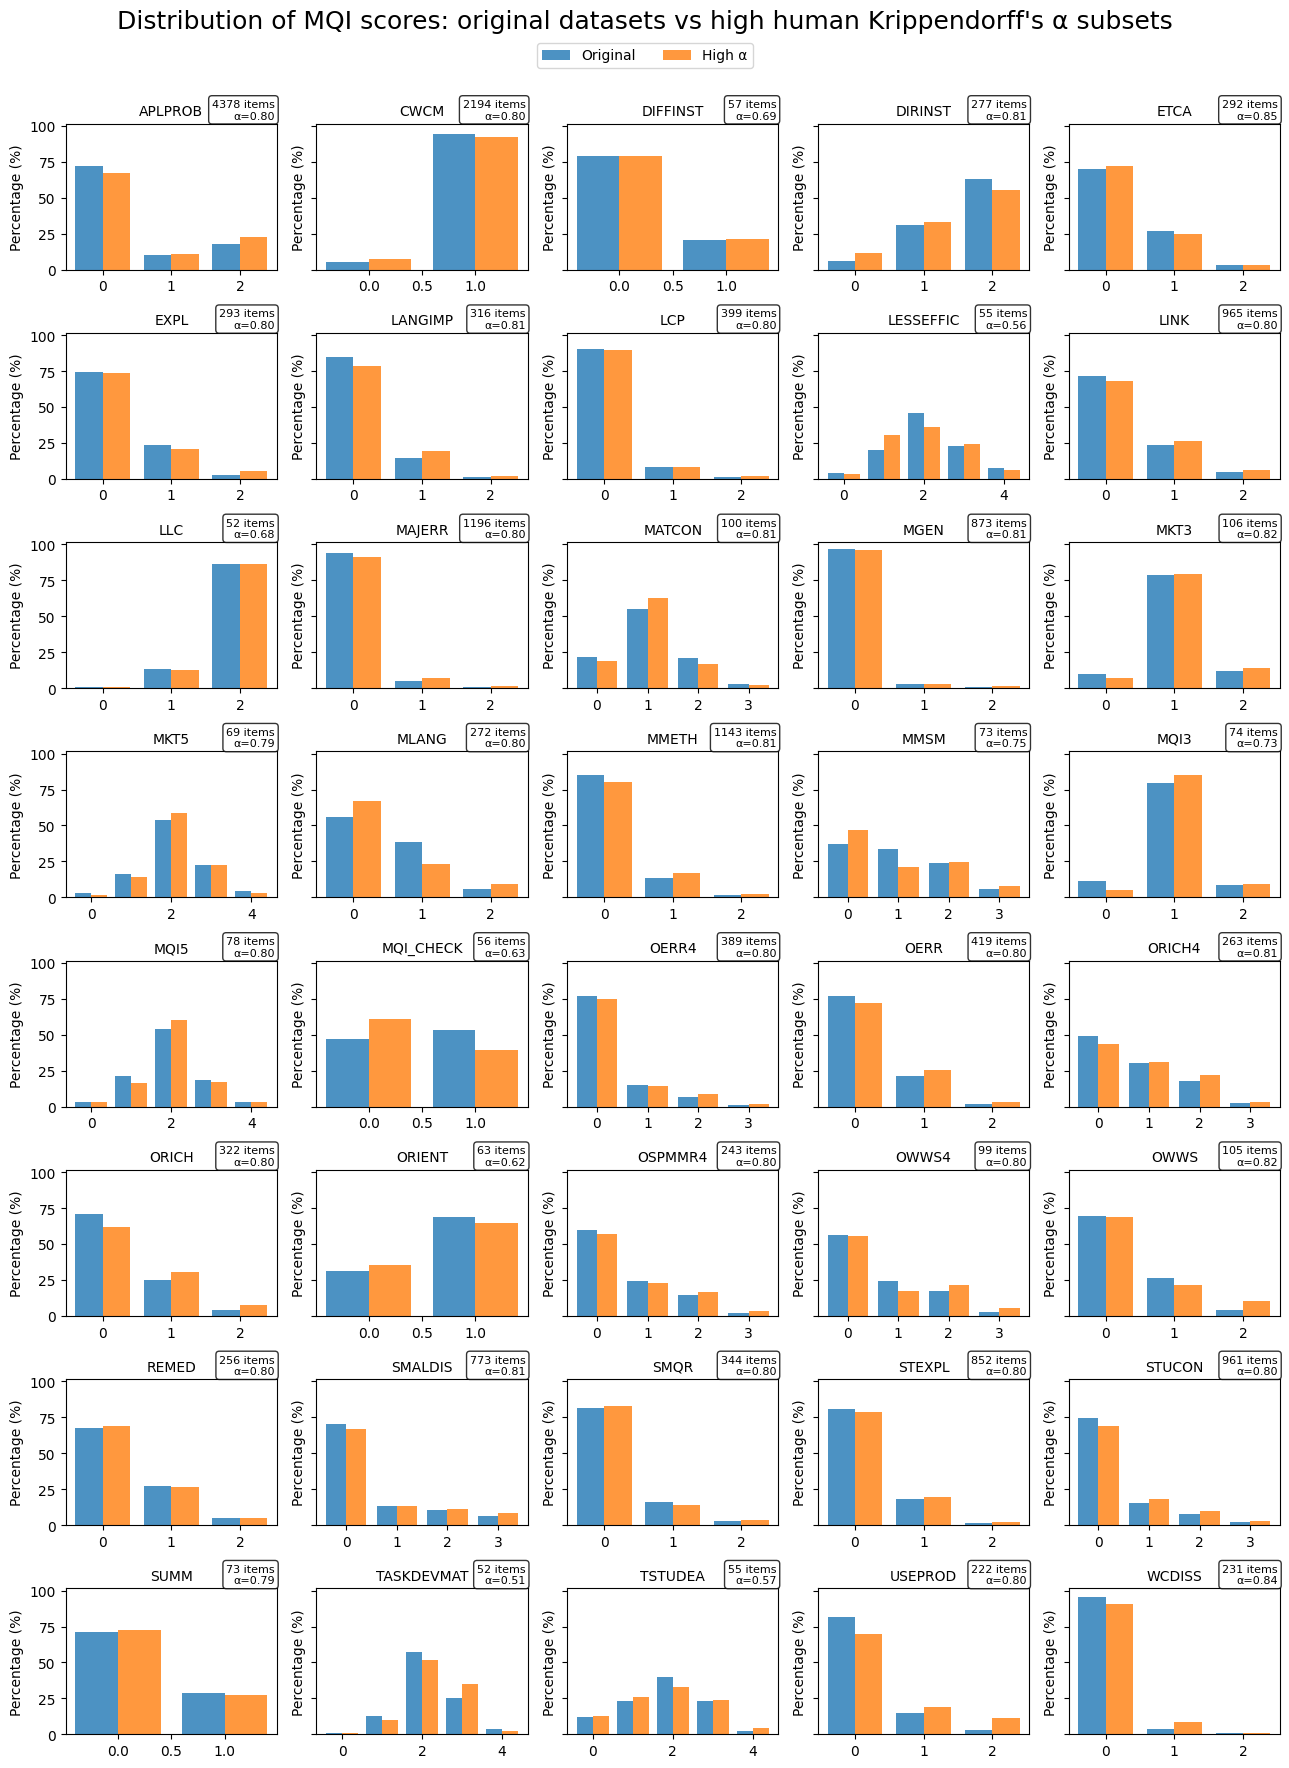

In [2]:
folder_path = "../datasets"
balanced_folder_path = "../balanced_subsets"
balanced_subset_files = os.listdir(balanced_folder_path)

fig, axes = plt.subplots(figsize=(13, 18), nrows=8, ncols=5, sharey=True)
axes = axes.flatten()

csv_files = [f for f in balanced_subset_files if f.endswith(".csv")]

records = []
for filename, ax in zip(csv_files, axes):
    parts = filename.split("_")
    code = "_".join(parts[1:3]) if "MQI_CHECK" in filename else parts[1]
    full_subset_name = f"MQI_{code}_dataset.csv"
    
    df1 = pd.read_csv(
        f"{folder_path}/{full_subset_name}",
        encoding="utf-8",
        low_memory=False,
    )
    df2 = pd.read_csv(
        f"{balanced_folder_path}/{filename}",
        encoding="utf-8",
        low_memory=False,
    )
    cols_to_drop = ['NCTETID', 'OBSID', 'DISTRICT', 'SCHOOLYEAR_SP', 'full_text', 'CHAPNUM']
    df1.drop(columns=cols_to_drop, inplace=True, errors="ignore")
    df2.drop(columns=cols_to_drop, inplace=True, errors="ignore")

    # Keep track of alpha and length
    alpha = filename.split("_")[-1].replace(".csv", "")
    length = filename.split("_")[-2]

    records.append({
        "Variable": code,
        "Number of items": length,
        "Alpha": alpha
    })

    # Plot
    counts_1 = df1.stack().value_counts(normalize=True) * 100
    counts_2 = df2.stack().value_counts(normalize=True) * 100
    
    index = sorted(set(counts_1.index).union(counts_2.index))
    c1 = counts_1.reindex(index, fill_value=0)
    c2 = counts_2.reindex(index, fill_value=0)

    x = np.arange(len(index))
    ax.bar(x - 0.2, c1, width=0.4, alpha=0.8)
    ax.bar(x + 0.2, c2, width=0.4, alpha=0.8)

    alpha = filename.split("_")[-1].replace(".csv", "")
    length = filename.split("_")[-2]
    info = f"{length} items\nα={alpha}"
    ax.text(
        0.99, 1.02,
        info,
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment="bottom",
        horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    ax.set_ylabel("Percentage (%)")
    ax.set_title(code, fontsize=10)
    
fig.suptitle("Distribution of MQI scores: original datasets vs high human Krippendorff's α subsets", fontsize=18)
fig.legend(
    ["Original", "High α"],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=2
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [7]:
summary_table = pd.DataFrame(records)
summary_table["Number of items"] = pd.to_numeric(summary_table["Number of items"])
summary_table["Alpha"] = pd.to_numeric(summary_table["Alpha"])
summary_table

,Variable,Number of items,Alpha
0,APLPROB,4378,0.80
1,CWCM,2194,0.80
2,DIFFINST,57,0.69
3,DIRINST,277,0.81
4,ETCA,292,0.85
5,EXPL,293,0.80
6,LANGIMP,316,0.81
7,LCP,399,0.80
8,LESSEFFIC,55,0.56
9,LINK,965,0.80


In [8]:
# To read the dict
with open("../../full_dictionnary_flash-lite_short-reasoning_examples.pkl", "rb") as f:
    my_dico_FL = pickle.load(f)

rows_ac_FL = []

for var, info in my_dico_FL.items():
    results = info["gwet_results"]
    res_key = next(iter(results)) # take first result key: "streamlit_analysis_iteration_1"
    agg = results[res_key]["aggregated_metrics"]

    rows_ac_FL.append({
        "Variable": var,
        "AC": agg["ac_human_panel_mean"],
    })

gwet_df_FL = pd.DataFrame(rows_ac_FL)

summary_table = (
    summary_table
    .merge(gwet_df_FL, on="Variable", how="left", validate="one_to_one")
)
summary_table

,Variable,Number of items,Alpha,AC
0,APLPROB,4378,0.80,0.86334
1,CWCM,2194,0.80,0.96832
2,DIFFINST,57,0.69,0.84232
3,DIRINST,277,0.81,0.88634
4,ETCA,292,0.85,0.96299
5,EXPL,293,0.80,0.94063
6,LANGIMP,316,0.81,0.96629
7,LCP,399,0.80,0.98290
8,LESSEFFIC,55,0.56,0.83413
9,LINK,965,0.80,0.92029


In [9]:
print("NUMBER OF ITEMS")
print("Mean:", summary_table["Number of items"].mean())
print("Standard deviation:", summary_table["Number of items"].std())
print("Min:", summary_table["Number of items"].min())
print("Max:", summary_table["Number of items"].max())
print()
print("KRIPPENDORFF'S ALPHAs")
print("Mean:", summary_table["Alpha"].mean())
print("Standard deviation:", summary_table["Alpha"].std())
print("Min:", summary_table["Alpha"].min())
print("Max:", summary_table["Alpha"].max())
print()
print("GWET'S AC2")
print("Mean:", summary_table["AC"].mean())
print("Standard deviation:", summary_table["AC"].std())
print("Min:", summary_table["AC"].min())
print("Max:", summary_table["AC"].max())

NUMBER OF ITEMS
Mean: 476.0
Standard deviation: 769.8099998684324
Min: 52
Max: 4378

KRIPPENDORFF'S ALPHAs
Mean: 0.768
Standard deviation: 0.080803655667493
Min: 0.51
Max: 0.85

GWET'S AC2
Mean: 0.9129897368421053
Standard deviation: 0.07577291306253792
Min: 0.65854
Max: 0.98946
